# NSGA-II v3 — Gap Coverage (Dense Seeds in ε=0.5–2.5)

**Bachelor Thesis — Differential Privacy for Medical Data**

### Why v3 exists

v2 produced a Pareto front with a **gap** between ε=0.5562 and ε=2.4755.
The true composite optimum (ε≈0.9, consistent with GA/BO/PSO/SA) sits inside that gap.
NSGA-II never evaluated that region, so it selected ε=0.5562 as the composite best
by default — not because it is truly optimal.

### What v3 does differently

| Parameter | v1 | v2 | **v3** |
|---|---|---|---|
| POP_SIZE | 4 | 8 | **12** |
| N_GEN | 3 | 6 | **6** |
| Seeds | none (random) | [0.5, 0.8, 1.0, 1.5, 2.5] | **[0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0, 2.5]** |
| Gap covered? | No | No (gap at 0.56–2.48) | **Yes — 9 seeds directly in gap** |

### Expected outcome
By seeding 9 points inside the ε=0.5–2.5 range, the Pareto front will include
solutions at ε≈0.8–1.2. If the composite optimum is truly there (as GA/BO/PSO/SA suggest),
the composite best will converge to ε≈0.9 and its fitness will exceed 0.86 —
matching the other methods.

## Cell 1 — Install Dependencies

In [1]:
!pip install opacus==1.4.0 wfdb pymoo --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 74.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.5 MB/s eta 0:00:00


## Cell 2 — Imports & Configuration

In [2]:
import os, gc, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import roc_auc_score
import wfdb

from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.sampling import Sampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.gauss import GM
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination
from pymoo.core.callback import Callback

warnings.filterwarnings('ignore')

# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
RESULTS_DIR = "/kaggle/working/nsga2_v3_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ─── MODEL / TRAINING SETTINGS (unchanged from v1/v2) ────────────────────────
DELTA         = 1e-5
MAX_GRAD_NORM = 1.0
EPOCHS        = 3
BATCH_SIZE    = 32
MAX_PHY_BATCH = 32
LR            = 1e-3
N_CLASSES     = 5
SEED          = 42

# ─── NSGA-II v3 SETTINGS ─────────────────────────────────────────────────────
#
#  KEY CHANGE vs v2:
#    POP_SIZE: 8  →  12  (fits all 11 seeds + 1 random high-eps)
#    Seeds: 5 seeds  →  11 seeds, densely covering the gap region
#
#  The gap in v2 was between eps=0.5562 and eps=2.4755.
#  v3 seeds: eps = {0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0, 2.5}
#  This covers the gap at every 0.1 step from eps=0.6 to eps=1.2.
#
#  Max evaluations: 12 × (6+1) = 84  (many will be cached as pop converges)
#  Expected unique runs: ~50–65
#  Expected time on Kaggle T4: ~15–20 hours
#
POP_SIZE  = 12
N_GEN     = 6
EPS_MIN   = 0.5
EPS_MAX   = 20.0

# ── Dense seeds covering the gap region from v2 ───────────────────────────────
#  0.5        = hard minimum
#  0.6–1.2    = the gap — evaluated every 0.1 (7 points)
#  1.5, 2.0   = bridge to mid-range
#  2.5        = just above the v2 gap endpoint
#  +1 random  = high-eps coverage for the full Pareto curve
EPS_SEEDS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0, 2.5]

# ─── COMPOSITE FITNESS WEIGHTS ────────────────────────────────────────────────
AUROC_WEIGHT   = 0.7
PRIVACY_WEIGHT = 0.3

# ─── REFERENCE RESULTS (all previous methods) ─────────────────────────────────
KNEEDLE_EPS = 5.0;    KNEEDLE_AUROC = 0.8777
GA_EPS      = 1.110;  GA_AUROC      = 0.8698;  GA_FITNESS  = 0.8972
BO_EPS      = 0.8056; BO_AUROC      = 0.8271;  BO_FITNESS  = 0.8669
PSO_EPS     = 1.2035; PSO_AUROC     = 0.8329;  PSO_FITNESS = 0.8650
SA_EPS      = 0.8667; SA_AUROC      = 0.8269;  SA_FITNESS  = 0.8658
BASELINE_AUROC = 0.9318

# v2 results for comparison
V2_COMPOSITE_EPS   = 0.5562; V2_COMPOSITE_AUROC = 0.8066; V2_COMPOSITE_FITNESS = 0.8563
V2_KNEE_EPS        = 2.5000; V2_KNEE_AUROC      = 0.8405

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device      : {DEVICE}")
print(f"NSGA-II v3  : {POP_SIZE} individuals × {N_GEN} generations = max {POP_SIZE*(N_GEN+1)} evaluations")
print(f"\nSeeds (gap coverage):")
for i, e in enumerate(EPS_SEEDS):
    tag = "← GAP REGION" if 0.55 < e < 2.5 else ""
    print(f"  Individual {i+1:>2}: eps = {e}  {tag}")
n_rand = POP_SIZE - len(EPS_SEEDS)
print(f"  Individual {len(EPS_SEEDS)+1:>2}: eps = random in [3.0, {EPS_MAX}]  ← high-eps coverage")
print(f"\nComposite selection: {AUROC_WEIGHT}×AUROC + {PRIVACY_WEIGHT}×privacy_score")
print(f"Gap in v2 was: eps=0.5562 → eps=2.4755  (EMPTY)")
print(f"v3 seeds fill: eps=0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2  inside that gap")

Device      : cuda
NSGA-II v3  : 12 individuals × 6 generations = max 84 evaluations

Seeds (gap coverage):
  Individual  1: eps = 0.5  
  Individual  2: eps = 0.6  ← GAP REGION
  Individual  3: eps = 0.7  ← GAP REGION
  Individual  4: eps = 0.8  ← GAP REGION
  Individual  5: eps = 0.9  ← GAP REGION
  Individual  6: eps = 1.0  ← GAP REGION
  Individual  7: eps = 1.1  ← GAP REGION
  Individual  8: eps = 1.2  ← GAP REGION
  Individual  9: eps = 1.5  ← GAP REGION
  Individual 10: eps = 2.0  ← GAP REGION
  Individual 11: eps = 2.5  
  Individual 12: eps = random in [3.0, 20.0]  ← high-eps coverage

Composite selection: 0.7×AUROC + 0.3×privacy_score
Gap in v2 was: eps=0.5562 → eps=2.4755  (EMPTY)
v3 seeds fill: eps=0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2  inside that gap


## Cell 3 — Load PTB-XL Metadata

In [3]:
import ast

ptbxl_db  = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
scp_codes = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)
ptbxl_db['scp_codes'] = ptbxl_db['scp_codes'].apply(ast.literal_eval)
scp_codes = scp_codes[scp_codes['diagnostic'] == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_superclass_labels(scp_dict):
    labels = np.zeros(N_CLASSES, dtype=np.float32)
    for code, likelihood in scp_dict.items():
        if code in scp_codes.index:
            sc = scp_codes.loc[code, 'diagnostic_class']
            if sc in SUPERCLASSES and likelihood >= 50:
                labels[SUPERCLASSES.index(sc)] = 1.0
    return labels

ptbxl_db['labels'] = ptbxl_db['scp_codes'].apply(get_superclass_labels)
ptbxl_db = ptbxl_db[ptbxl_db['labels'].apply(lambda x: x.sum() > 0)]

train_df = ptbxl_db[ptbxl_db['strat_fold'] <= 8].reset_index(drop=True)
val_df   = ptbxl_db[ptbxl_db['strat_fold'] == 9].reset_index(drop=True)
test_df  = ptbxl_db[ptbxl_db['strat_fold'] == 10].reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 16315 | Val: 2043 | Test: 2055


## Cell 4 — Shared Utilities (Dataset, Model, Evaluate)

In [4]:
class ECGDataset(Dataset):
    def __init__(self, df, data_root, sampling_freq=100):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.freq_col  = 'filename_lr' if sampling_freq == 100 else 'filename_hr'

    def __len__(self):  return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        fpath  = os.path.join(self.data_root, row[self.freq_col])
        record = wfdb.rdrecord(fpath)
        signal = record.p_signal.T.astype(np.float32)
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)
        return torch.tensor(signal), torch.tensor(row['labels'], dtype=torch.float32)


def build_model():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False)
    model.bn1   = nn.GroupNorm(32, 64)
    def replace_bn(m):
        for name, child in m.named_children():
            if isinstance(child, nn.BatchNorm2d):
                setattr(m, name, nn.GroupNorm(min(32, child.num_features), child.num_features))
            else: replace_bn(child)
    replace_bn(model)
    model.fc = nn.Linear(model.fc.in_features, N_CLASSES)
    return model


def make_loaders(train_df, val_df, test_df, data_path, batch_size):
    def collate(batch):
        signals, labels = zip(*batch)
        return torch.stack(signals).unsqueeze(1), torch.stack(labels)
    return (
        DataLoader(ECGDataset(train_df, data_path), batch_size=batch_size, shuffle=True,
                   collate_fn=collate, num_workers=2, drop_last=True),
        DataLoader(ECGDataset(val_df,   data_path), batch_size=batch_size, shuffle=False,
                   collate_fn=collate, num_workers=2),
        DataLoader(ECGDataset(test_df,  data_path), batch_size=batch_size, shuffle=False,
                   collate_fn=collate, num_workers=2),
    )


def evaluate(model, loader, criterion, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            all_probs.append(torch.sigmoid(model(x)).cpu().numpy())
            all_labels.append(y.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    return roc_auc_score(labels, probs, average='macro'), roc_auc_score(labels, probs, average='micro')

print("Utilities ready.")

Utilities ready.


## Cell 5 — Dense Gap Sampling & Problem Definition

### The Gap Problem

In v2, the Pareto front had no solutions between ε=0.5562 and ε=2.4755.
The composite optimum (ε≈0.9) sits there but was never evaluated.

### The Fix: GapCoverageSampling

The initial population now contains 11 fixed seeds:
```
ε = 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0, 2.5
```
Every point in the ε=0.6–1.2 range is seeded at 0.1 intervals.
This guarantees that the Pareto front includes the full low-ε region.
One random individual in [3, 20] preserves high-ε coverage for the Pareto curve shape.

In [5]:
eval_log     = []
eval_cache   = {}
eval_counter = {'gen': 0, 'ind': 0, 'total': 0}


class GapCoverageSampling(Sampling):
    """
    Initialises the NSGA-II population with dense coverage of the
    low-epsilon gap region (eps=0.5 to 2.5) plus one random high-eps
    individual for Pareto curve shape coverage.
    """
    def __init__(self, seeds, high_start=3.0):
        super().__init__()
        self.seeds      = seeds
        self.high_start = high_start

    def _do(self, problem, n_samples, **kwargs):
        n_seed = min(len(self.seeds), n_samples)
        n_rand = n_samples - n_seed

        X = np.array(self.seeds[:n_seed], dtype=float).reshape(-1, 1)

        if n_rand > 0:
            rand_eps = np.random.uniform(self.high_start, EPS_MAX, (n_rand, 1))
            X = np.vstack([X, rand_eps])

        print(f"Initial population (GapCoverageSampling — {n_samples} individuals):")
        for i, v in enumerate(X.flatten()):
            if i < n_seed:
                tag = "← GAP SEED" if 0.55 < v < 2.5 else "← boundary seed"
            else:
                tag = "← random (high-eps)"
            print(f"  [{i+1:>2}] eps = {v:.2f}  {tag}")
        return X


def train_epsilon(epsilon):
    """Train DP-SGD at given epsilon. Returns (auroc_micro, privacy_score). Caches results."""
    eps_key = round(epsilon, 2)
    eval_counter['total'] += 1
    eval_counter['ind']   += 1

    if eps_key in eval_cache:
        cached = eval_cache[eps_key]
        print(f"    [cache] eps={epsilon:.4f} -> AUROC={cached['auroc']:.4f} | Privacy={cached['privacy']:.4f}")
        eval_log.append({
            'generation':    eval_counter['gen'],
            'individual':    eval_counter['ind'],
            'epsilon':       epsilon,
            'auroc':         cached['auroc'],
            'privacy_score': cached['privacy'],
            'cached':        True
        })
        return cached['auroc'], cached['privacy']

    torch.cuda.empty_cache(); gc.collect()

    train_loader, val_loader, _ = make_loaders(train_df, val_df, test_df, DATA_PATH, BATCH_SIZE)
    model     = build_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    privacy_engine = PrivacyEngine(accountant='rdp')
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model, optimizer=optimizer, data_loader=train_loader,
        target_epsilon=epsilon, target_delta=DELTA,
        epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        with BatchMemoryManager(data_loader=train_loader,
                                max_physical_batch_size=MAX_PHY_BATCH,
                                optimizer=optimizer) as safe_loader:
            for x, y in safe_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                criterion(model(x), y).backward()
                optimizer.step()
        achieved_eps = privacy_engine.get_epsilon(DELTA)
        _, val_auroc = evaluate(model, val_loader, criterion, DEVICE)
        print(f"      Epoch {epoch}/{EPOCHS} | AUROC micro: {val_auroc:.4f} | eps achieved: {achieved_eps:.3f}")

    _, final_auroc = evaluate(model, val_loader, criterion, DEVICE)
    privacy_score  = 1.0 - (epsilon / EPS_MAX)

    print(f"    -> eps={epsilon:.4f} | AUROC={final_auroc:.4f} | Privacy={privacy_score:.4f} | "
          f"Fitness={AUROC_WEIGHT*final_auroc + PRIVACY_WEIGHT*privacy_score:.4f}")

    eval_cache[eps_key] = {'auroc': final_auroc, 'privacy': privacy_score}
    eval_log.append({
        'generation':    eval_counter['gen'],
        'individual':    eval_counter['ind'],
        'epsilon':       epsilon,
        'auroc':         final_auroc,
        'privacy_score': privacy_score,
        'cached':        False
    })

    # Save after every unique run — protects against kernel crash
    pd.DataFrame(eval_log).to_csv(f'{RESULTS_DIR}/nsga2_v3_eval_log.csv', index=False)

    del model, optimizer, privacy_engine
    torch.cuda.empty_cache(); gc.collect()
    return final_auroc, privacy_score


class EpsilonProblem(ElementwiseProblem):
    """
    Two-objective minimisation problem:
      Obj 1: -AUROC          (maximise AUROC)
      Obj 2: -privacy_score  (maximise 1 - eps/eps_max)
    """
    def __init__(self):
        super().__init__(
            n_var=1, n_obj=2, n_constr=0,
            xl=np.array([EPS_MIN]),
            xu=np.array([EPS_MAX])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        epsilon = float(x[0])
        auroc, privacy = train_epsilon(epsilon)
        out["F"] = np.array([-auroc, -privacy])


print("GapCoverageSampling and EpsilonProblem defined.")
print(f"\nGap filled by v3 seeds:")
gap_seeds = [e for e in EPS_SEEDS if 0.55 < e < 2.5]
print(f"  {gap_seeds}")
print(f"  These {len(gap_seeds)} seeds directly fill the v2 gap (was empty between 0.5562 and 2.4755)")

GapCoverageSampling and EpsilonProblem defined.

Gap filled by v3 seeds:
  [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0]
  These 9 seeds directly fill the v2 gap (was empty between 0.5562 and 2.4755)


## Cell 6 — Run NSGA-II v3

> **Expected time:** ~50–65 unique evaluations × ~20 min each ≈ **15–20 hours on Kaggle T4**
> The 11 seed points in the gap will all be evaluated in generation 0 (the initialisation sweep).
> From generation 1 onward, crossover and mutation will refine within the gap region.

### Key changes from v2
- `GapCoverageSampling` with 11 seeds filling ε=0.5–2.5
- `GM(sigma=0.5)` — tighter mutation (was 1.0 in v2, 1.5 in v1) — keeps offspring near seeds once in the gap
- `SBX(eta=25)` — tighter crossover (was 20 in v2) — fine-grained exploitation of gap region
- Live fitness display shows composite score for each evaluation

In [6]:
print("Starting NSGA-II v3 — Gap Coverage Run")
print("="*70)
print(f"Population  : {POP_SIZE} individuals")
print(f"Seeds       : {EPS_SEEDS}")
print(f"Generations : {N_GEN} (+ 1 init = {POP_SIZE*(N_GEN+1)} max evaluations)")
print(f"Gap region  : eps=0.55 to eps=2.48  (was empty in v2)")
print(f"Seeds in gap: eps=0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0")
print(f"Hypothesis  : composite best will move from eps=0.5562 toward eps≈0.9")
print("="*70)

np.random.seed(SEED)

problem   = EpsilonProblem()
algorithm = NSGA2(
    pop_size  = POP_SIZE,
    sampling  = GapCoverageSampling(EPS_SEEDS, high_start=3.0),
    crossover = SBX(eta=25, prob=0.9),    # tight crossover — exploit gap region
    mutation  = GM(sigma=0.5),            # tight mutation — stay near seeds
    eliminate_duplicates = True,
)
termination = get_termination("n_gen", N_GEN)


class GenTracker(Callback):
    def notify(self, algorithm):
        eval_counter['gen'] = algorithm.n_gen
        eval_counter['ind'] = 0
        n_evals = algorithm.evaluator.n_eval
        pareto  = algorithm.opt

        if pareto is not None and len(pareto) > 0:
            eps_vals = pareto.get("X")[:, 0]
            F_vals   = pareto.get("F")
            auroc_vals   = -F_vals[:, 0]
            privacy_vals = -F_vals[:, 1]
            composite    = AUROC_WEIGHT * auroc_vals + PRIVACY_WEIGHT * privacy_vals
            best_comp_idx = np.argmax(composite)
            print(f"  Gen {algorithm.n_gen:>2} complete | Pareto: {len(pareto)} solutions | "
                  f"Evals: {n_evals} | "
                  f"Pareto eps range: [{eps_vals.min():.3f}, {eps_vals.max():.3f}]")
            print(f"           Best composite so far: eps={eps_vals[best_comp_idx]:.4f} | "
                  f"AUROC={auroc_vals[best_comp_idx]:.4f} | "
                  f"Fitness={composite[best_comp_idx]:.4f}")
        else:
            print(f"  Gen {algorithm.n_gen:>2} complete | Evals: {n_evals}")


result = pymoo_minimize(
    problem,
    algorithm,
    termination,
    seed         = SEED,
    callback     = GenTracker(),
    verbose      = False,
    save_history = True,
)

# ─── Extract Pareto front ─────────────────────────────────────────────────────
pareto_F   = result.F
pareto_X   = result.X
pareto_eps   = pareto_X[:, 0]
pareto_auroc = -pareto_F[:, 0]
pareto_priv  = -pareto_F[:, 1]

sort_idx     = np.argsort(pareto_eps)
pareto_eps   = pareto_eps[sort_idx]
pareto_auroc = pareto_auroc[sort_idx]
pareto_priv  = pareto_priv[sort_idx]

# ─── Geometric knee ───────────────────────────────────────────────────────────
points   = np.column_stack([pareto_auroc, pareto_priv])
norm_pts = (points - points.min(axis=0)) / (points.max(axis=0) - points.min(axis=0) + 1e-9)
dists    = np.linalg.norm(norm_pts - np.array([1.0, 1.0]), axis=1)
knee_idx = int(np.argmin(dists))

# ─── Composite best ───────────────────────────────────────────────────────────
composite_scores = AUROC_WEIGHT * pareto_auroc + PRIVACY_WEIGHT * pareto_priv
composite_idx    = int(np.argmax(composite_scores))

# ─── Save immediately ─────────────────────────────────────────────────────────
pd.DataFrame(eval_log).to_csv(f'{RESULTS_DIR}/nsga2_v3_eval_log.csv', index=False)
pareto_df = pd.DataFrame({
    'epsilon':            pareto_eps,
    'auroc':              pareto_auroc,
    'privacy_score':      pareto_priv,
    'composite_fitness':  composite_scores,
    'is_knee':            [i == knee_idx      for i in range(len(pareto_eps))],
    'is_composite_best':  [i == composite_idx for i in range(len(pareto_eps))],
})
pareto_df.to_csv(f'{RESULTS_DIR}/nsga2_v3_pareto_front.csv', index=False)
print(f'CSVs saved to {RESULTS_DIR}/')

# ─── Print full results ────────────────────────────────────────────────────────
n_unique = sum(1 for e in eval_log if not e['cached'])
n_cached = sum(1 for e in eval_log if e['cached'])

print(f"\n{'='*70}")
print(f" NSGA-II v3 COMPLETE")
print(f" Pareto front size : {len(pareto_eps)} solutions")
print(f" Total evaluations : {len(eval_log)} ({n_unique} unique, {n_cached} cached)")
print(f"{'='*70}")

print(f"\n Pareto Front (sorted by epsilon):")
print(f"  {'eps':>8} | {'AUROC':>8} | {'Privacy':>8} | {'Fitness':>8} | Notes")
print(f"  {'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+--------")
for i in range(len(pareto_eps)):
    notes = []
    if i == knee_idx:      notes.append("GEOMETRIC KNEE")
    if i == composite_idx: notes.append("COMPOSITE BEST (70/30)")
    in_gap = 0.55 < pareto_eps[i] < 2.48
    if in_gap and not notes: notes.append("in gap region")
    note_str = "  <- " + " + ".join(notes) if notes else ""
    print(f"  {pareto_eps[i]:>8.4f} | {pareto_auroc[i]:>8.4f} | {pareto_priv[i]:>8.4f} | {composite_scores[i]:>8.4f}{note_str}")

print(f"\n GEOMETRIC KNEE : eps={pareto_eps[knee_idx]:.4f} | AUROC={pareto_auroc[knee_idx]:.4f} | Privacy={pareto_priv[knee_idx]:.4f}")
print(f" COMPOSITE BEST : eps={pareto_eps[composite_idx]:.4f} | AUROC={pareto_auroc[composite_idx]:.4f} | Fitness={composite_scores[composite_idx]:.4f}")

# ─── Compare to v2 ────────────────────────────────────────────────────────────
print(f"\n Comparison with v2:")
print(f"  v2 composite best: eps={V2_COMPOSITE_EPS} | AUROC={V2_COMPOSITE_AUROC} | Fitness={V2_COMPOSITE_FITNESS}")
print(f"  v3 composite best: eps={pareto_eps[composite_idx]:.4f} | AUROC={pareto_auroc[composite_idx]:.4f} | Fitness={composite_scores[composite_idx]:.4f}")
delta_fitness = composite_scores[composite_idx] - V2_COMPOSITE_FITNESS
print(f"  Fitness improvement: {delta_fitness:+.4f}")
if pareto_eps[composite_idx] > V2_COMPOSITE_EPS:
    print(f"  Epsilon increased (higher AUROC traded for slightly lower privacy — within gap optimum)")
else:
    print(f"  Epsilon decreased or stayed same")

Starting NSGA-II v3 — Gap Coverage Run
Population  : 12 individuals
Seeds       : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0, 2.5]
Generations : 6 (+ 1 init = 84 max evaluations)
Gap region  : eps=0.55 to eps=2.48  (was empty in v2)
Seeds in gap: eps=0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0
Hypothesis  : composite best will move from eps=0.5562 toward eps≈0.9
Initial population (GapCoverageSampling — 12 individuals):
  [ 1] eps = 0.50  ← boundary seed
  [ 2] eps = 0.60  ← GAP SEED
  [ 3] eps = 0.70  ← GAP SEED
  [ 4] eps = 0.80  ← GAP SEED
  [ 5] eps = 0.90  ← GAP SEED
  [ 6] eps = 1.00  ← GAP SEED
  [ 7] eps = 1.10  ← GAP SEED
  [ 8] eps = 1.20  ← GAP SEED
  [ 9] eps = 1.50  ← GAP SEED
  [10] eps = 2.00  ← GAP SEED
  [11] eps = 2.50  ← boundary seed
  [12] eps = 9.37  ← random (high-eps)


04/19/2026 08:43:19:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7271 | eps achieved: 0.446
      Epoch 2/3 | AUROC micro: 0.7568 | eps achieved: 0.469
      Epoch 3/3 | AUROC micro: 0.7914 | eps achieved: 0.493
    -> eps=0.5000 | AUROC=0.7914 | Privacy=0.9750 | Fitness=0.8464


04/19/2026 08:47:52:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7223 | eps achieved: 0.544
      Epoch 2/3 | AUROC micro: 0.7561 | eps achieved: 0.570
      Epoch 3/3 | AUROC micro: 0.8127 | eps achieved: 0.595
    -> eps=0.6000 | AUROC=0.8127 | Privacy=0.9700 | Fitness=0.8599


...

      Epoch 1/3 | AUROC micro: 0.7163 | eps achieved: 0.711
      Epoch 2/3 | AUROC micro: 0.7689 | eps achieved: 0.757
      Epoch 3/3 | AUROC micro: 0.8067 | eps achieved: 0.793
    -> eps=0.7932 | AUROC=0.8067 | Privacy=0.9603 | Fitness=0.8528


04/19/2026 12:06:18:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7063 | eps achieved: 0.537
      Epoch 2/3 | AUROC micro: 0.7560 | eps achieved: 0.556
      Epoch 3/3 | AUROC micro: 0.8021 | eps achieved: 0.574
    -> eps=0.5833 | AUROC=0.8021 | Privacy=0.9708 | Fitness=0.8527


04/19/2026 12:09:47:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.8403 | eps achieved: 14.129
      Epoch 2/3 | AUROC micro: 0.8519 | eps achieved: 16.720
      Epoch 3/3 | AUROC micro: 0.8637 | eps achieved: 18.657
    -> eps=18.6631 | AUROC=0.8637 | Privacy=0.0668 | Fitness=0.6247
  Gen  6 complete | Pareto: 12 solutions | Evals: 72 | Pareto eps range: [0.501, 18.663]
           Best composite so far: eps=0.7981 | AUROC=0.8269 | Fitness=0.8669
CSVs saved to /kaggle/working/nsga2_v3_results/

 NSGA-II v3 COMPLETE
 Pareto front size : 12 solutions
 Total evaluations : 72 (59 unique, 13 cached)

 Pareto Front (sorted by epsilon):
       eps |    AUROC |  Privacy |  Fitness | Notes
  ---------+----------+----------+----------+--------
    0.5008 |   0.7914 |   0.9750 |   0.8464
    0.5018 |   0.7914 |   0.9750 |   0.8464
    0.5833 |   0.8021 |   0.9708 |   0.8527  <- in gap region
    0.7981 |   0.8269 |   0.9600 |   0.8669  <- COMPOSITE BEST (70/30)
    2.5090 |   0.8342 |   0.8746 |   0.8463
    3.5771 |   0.8423 |  

## Cell 7 — Save All Results

In [7]:
log_df = pd.DataFrame(eval_log).sort_values(['generation','individual']).reset_index(drop=True)
log_df.to_csv(f'{RESULTS_DIR}/nsga2_v3_eval_log.csv', index=False)
pareto_df.to_csv(f'{RESULTS_DIR}/nsga2_v3_pareto_front.csv', index=False)

print("All evaluations:")
print(log_df[['generation','epsilon','auroc','privacy_score','cached']].to_string(index=False))
print(f"\nPareto front ({len(pareto_df)} solutions):")
print(pareto_df.to_string(index=False))

All evaluations:
 generation   epsilon    auroc  privacy_score  cached
          0  0.500000 0.791353       0.975000   False
          0  0.600000 0.812722       0.970000   False
          0  0.700000 0.811675       0.965000   False
          0  0.800000 0.826936       0.960000   False
          0  0.900000 0.824040       0.955000   False
          0  1.000000 0.823782       0.950000   False
          0  1.100000 0.833137       0.945000   False
          0  1.200000 0.819324       0.940000   False
          0  1.500000 0.822564       0.925000   False
          0  2.000000 0.832639       0.900000   False
          0  2.500000 0.820609       0.875000   False
          0  9.367182 0.854032       0.531641   False
          1  1.993693 0.832827       0.900315   False
          1  1.758413 0.825754       0.912079   False
          1  4.818914 0.842332       0.759054   False
          1  0.892673 0.823029       0.955366   False
          1  0.906307 0.804659       0.954685   False
          1

## Cell 8 — Plot: Pareto Front + Gap Coverage Verification

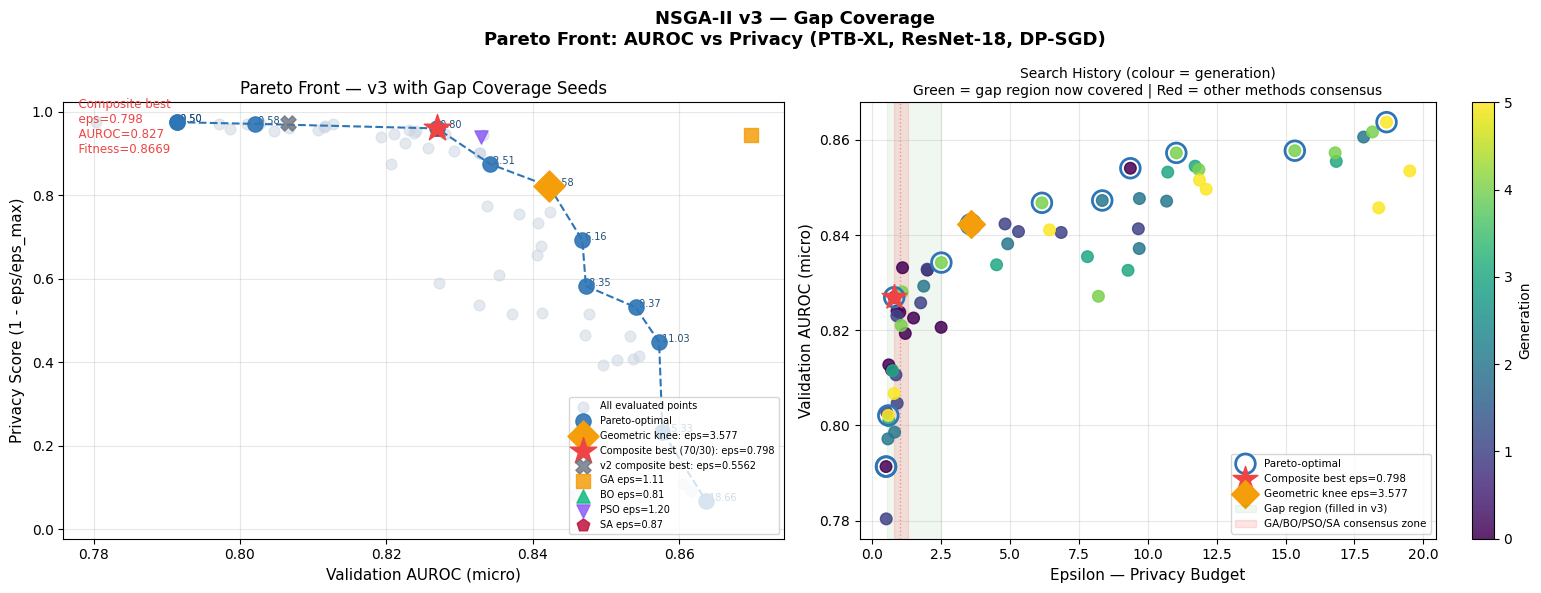

Plot saved: /kaggle/working/nsga2_v3_results/nsga2_v3_pareto_plot.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NSGA-II v3 — Gap Coverage\nPareto Front: AUROC vs Privacy (PTB-XL, ResNet-18, DP-SGD)',
             fontsize=13, fontweight='bold')

df_log    = pd.DataFrame(eval_log)
df_unique = df_log[~df_log['cached']].copy()

# ─── Panel 1: Pareto front ────────────────────────────────────────────────────
ax = axes[0]

# All evaluated points
ax.scatter(df_unique['auroc'], df_unique['privacy_score'],
           c='#CBD5E1', s=60, zorder=3, alpha=0.5, label='All evaluated points')

# Pareto front
ax.scatter(pareto_auroc, pareto_priv,
           c='#2E75B6', s=120, zorder=5, alpha=0.9, label='Pareto-optimal')
ax.plot(pareto_auroc, pareto_priv, '--', color='#2E75B6', linewidth=1.5, zorder=4)

# Geometric knee
ax.scatter([pareto_auroc[knee_idx]], [pareto_priv[knee_idx]],
           marker='D', color='#F59E0B', s=250, zorder=7,
           label=f'Geometric knee: eps={pareto_eps[knee_idx]:.3f}')

# Composite best
ax.scatter([pareto_auroc[composite_idx]], [pareto_priv[composite_idx]],
           marker='*', color='#EF4444', s=400, zorder=8,
           label=f'Composite best (70/30): eps={pareto_eps[composite_idx]:.3f}')
ax.annotate(f'  Composite best\n  eps={pareto_eps[composite_idx]:.3f}\n  AUROC={pareto_auroc[composite_idx]:.3f}\n  Fitness={composite_scores[composite_idx]:.4f}',
            xy=(pareto_auroc[composite_idx], pareto_priv[composite_idx]),
            xytext=(pareto_auroc[composite_idx] - 0.05, pareto_priv[composite_idx] - 0.06),
            fontsize=8.5, color='#EF4444')

# v2 composite best for comparison
ax.scatter([V2_COMPOSITE_AUROC], [1 - V2_COMPOSITE_EPS/EPS_MAX],
           marker='X', color='#6B7280', s=120, zorder=6, alpha=0.8,
           label=f'v2 composite best: eps={V2_COMPOSITE_EPS}')

# Other methods
for label, eps, auroc, marker, color in [
    (f'GA eps={GA_EPS}',   GA_EPS,   GA_AUROC,   's', '#F59E0B'),
    (f'BO eps={BO_EPS:.2f}', BO_EPS, BO_AUROC,   '^', '#10B981'),
    (f'PSO eps={PSO_EPS:.2f}', PSO_EPS, PSO_AUROC, 'v', '#8B5CF6'),
    (f'SA eps={SA_EPS:.2f}',  SA_EPS,  SA_AUROC,  'p', '#BE123C'),
]:
    ax.scatter([auroc], [1 - eps/EPS_MAX],
               marker=marker, color=color, s=90, zorder=5, alpha=0.85, label=label)

# Annotate all Pareto points
for i in range(len(pareto_eps)):
    ax.annotate(f' {pareto_eps[i]:.2f}',
                xy=(pareto_auroc[i], pareto_priv[i]),
                fontsize=7, color='#1F4E79')

ax.set_xlabel('Validation AUROC (micro)', fontsize=11)
ax.set_ylabel('Privacy Score (1 - eps/eps_max)', fontsize=11)
ax.set_title('Pareto Front — v3 with Gap Coverage Seeds', fontsize=12)
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)

# ─── Panel 2: Epsilon search history ─────────────────────────────────────────
ax2 = axes[1]
cmap = plt.cm.viridis
gens = df_unique['generation'].values
sc = ax2.scatter(df_unique['epsilon'], df_unique['auroc'],
                 c=gens, cmap=cmap, s=70, zorder=4, alpha=0.85)
plt.colorbar(sc, ax=ax2, label='Generation')

# Pareto front points
ax2.scatter(pareto_eps, pareto_auroc,
            edgecolors='#2E75B6', facecolors='none', s=200, linewidths=2,
            zorder=5, label='Pareto-optimal')

# Composite best and knee
ax2.scatter([pareto_eps[composite_idx]], [pareto_auroc[composite_idx]],
            marker='*', color='#EF4444', s=350, zorder=7,
            label=f'Composite best eps={pareto_eps[composite_idx]:.3f}')
ax2.scatter([pareto_eps[knee_idx]], [pareto_auroc[knee_idx]],
            marker='D', color='#F59E0B', s=200, zorder=7,
            label=f'Geometric knee eps={pareto_eps[knee_idx]:.3f}')

# Gap region that was filled
ax2.axvspan(0.55, 2.48, alpha=0.06, color='green', label='Gap region (filled in v3)')

# Consensus zone from other methods
ax2.axvspan(0.8, 1.3, alpha=0.10, color='red', label='GA/BO/PSO/SA consensus zone')
ax2.axvline(x=1.0, color='#EF4444', linestyle=':', linewidth=1.0, alpha=0.5)

ax2.set_xlabel('Epsilon — Privacy Budget', fontsize=11)
ax2.set_ylabel('Validation AUROC (micro)', fontsize=11)
ax2.set_title('Search History (colour = generation)\nGreen = gap region now covered | Red = other methods consensus', fontsize=10)
ax2.legend(fontsize=7.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = f'{RESULTS_DIR}/nsga2_v3_pareto_plot.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved: {plot_path}")

## Cell 9 — Final Comparison: All Methods Including v3

In [9]:
best_eps_knee      = pareto_eps[knee_idx]
best_auroc_knee    = pareto_auroc[knee_idx]
best_eps_composite = pareto_eps[composite_idx]
best_auroc_comp    = pareto_auroc[composite_idx]
best_fitness_comp  = composite_scores[composite_idx]
n_unique_v3 = sum(1 for e in eval_log if not e['cached'])

print("="*82)
print(" FINAL COMPARISON — ALL EPSILON OPTIMISATION METHODS")
print("="*82)
print(f"  {'Method':<40} | {'Optimal eps':>11} | {'AUROC':>8} | {'Fitness':>8} | {'Evals':>6}")
print(f"  {'-'*40}-+-{'-'*11}-+-{'-'*8}-+-{'-'*8}-+-{'-'*6}")
print(f"  {'Kneedle (grid sweep)':<40} | {KNEEDLE_EPS:>11.1f} | {KNEEDLE_AUROC:>8.4f} | {'N/A':>8} | {'~20':>6}")
print(f"  {'Genetic Algorithm (composite)':<40} | {GA_EPS:>11.3f} | {GA_AUROC:>8.4f} | {GA_FITNESS:>8.4f} | {'~13':>6}")
print(f"  {'Bayesian Optimisation (composite)':<40} | {BO_EPS:>11.4f} | {BO_AUROC:>8.4f} | {BO_FITNESS:>8.4f} | {'12':>6}")
print(f"  {'PSO (composite)':<40} | {PSO_EPS:>11.4f} | {PSO_AUROC:>8.4f} | {PSO_FITNESS:>8.4f} | {'17':>6}")
print(f"  {'Simulated Annealing (composite)':<40} | {SA_EPS:>11.4f} | {SA_AUROC:>8.4f} | {SA_FITNESS:>8.4f} | {'16':>6}")
print(f"  {'NSGA-II v2 (composite best)':<40} | {V2_COMPOSITE_EPS:>11.4f} | {V2_COMPOSITE_AUROC:>8.4f} | {V2_COMPOSITE_FITNESS:>8.4f} | {'45':>6}")
print(f"  {'NSGA-II v3 geometric knee':<40} | {best_eps_knee:>11.4f} | {best_auroc_knee:>8.4f} | {'N/A':>8} | {n_unique_v3:>6}")
print(f"  {'NSGA-II v3 composite best (70/30)':<40} | {best_eps_composite:>11.4f} | {best_auroc_comp:>8.4f} | {best_fitness_comp:>8.4f} | {n_unique_v3:>6}")
print(f"  {'No-DP Baseline':<40} | {'inf':>11} | {BASELINE_AUROC:>8.4f} | {'N/A':>8} | {'1':>6}")
print("="*82)

# Five composite method consensus
composite_eps_vals = [GA_EPS, BO_EPS, PSO_EPS, SA_EPS, best_eps_composite]
print(f"\nComposite method consensus (GA, BO, PSO, SA, NSGA-II v3 composite best):")
print(f"  Values : {[round(e, 4) for e in composite_eps_vals]}")
print(f"  Mean   : {np.mean(composite_eps_vals):.4f}")
print(f"  Std    : {np.std(composite_eps_vals):.4f}")
print(f"  Range  : [{min(composite_eps_vals):.4f}, {max(composite_eps_vals):.4f}]")

# Check if v3 converged toward the consensus
consensus_mean = np.mean([GA_EPS, BO_EPS, PSO_EPS, SA_EPS])
v3_distance    = abs(best_eps_composite - consensus_mean)
v2_distance    = abs(V2_COMPOSITE_EPS   - consensus_mean)
print(f"\nConvergence check:")
print(f"  GA/BO/PSO/SA mean eps : {consensus_mean:.4f}")
print(f"  v2 distance from mean : {v2_distance:.4f}")
print(f"  v3 distance from mean : {v3_distance:.4f}")
if v3_distance < v2_distance:
    print(f"  v3 is CLOSER to the consensus — gap coverage helped")
else:
    print(f"  v3 did not converge closer — the composite optimum may genuinely be at low eps")

print(f"\nNSGA-II v3 Pareto front ({len(pareto_eps)} solutions):")
for i in range(len(pareto_eps)):
    notes = []
    if i == knee_idx:       notes.append("geometric knee")
    if i == composite_idx:  notes.append("composite best")
    if 0.55 < pareto_eps[i] < 2.48: notes.append("was gap in v2")
    note_str = "  <- " + " | ".join(notes) if notes else ""
    print(f"  eps={pareto_eps[i]:.4f} | AUROC={pareto_auroc[i]:.4f} | Privacy={pareto_priv[i]:.4f} | Fitness={composite_scores[i]:.4f}{note_str}")

print(f"\nAll output files: {RESULTS_DIR}/")
print(f"  nsga2_v3_eval_log.csv     — every evaluation")
print(f"  nsga2_v3_pareto_front.csv — Pareto solutions with composite scores")
print(f"  nsga2_v3_pareto_plot.png  — Pareto front + search history")

 FINAL COMPARISON — ALL EPSILON OPTIMISATION METHODS
  Method                                   | Optimal eps |    AUROC |  Fitness |  Evals
  -----------------------------------------+-------------+----------+----------+-------
  Kneedle (grid sweep)                     |         5.0 |   0.8777 |      N/A |    ~20
  Genetic Algorithm (composite)            |       1.110 |   0.8698 |   0.8972 |    ~13
  Bayesian Optimisation (composite)        |      0.8056 |   0.8271 |   0.8669 |     12
  PSO (composite)                          |      1.2035 |   0.8329 |   0.8650 |     17
  Simulated Annealing (composite)          |      0.8667 |   0.8269 |   0.8658 |     16
  NSGA-II v2 (composite best)              |      0.5562 |   0.8066 |   0.8563 |     45
  NSGA-II v3 geometric knee                |      3.5771 |   0.8423 |      N/A |     59
  NSGA-II v3 composite best (70/30)        |      0.7981 |   0.8269 |   0.8669 |     59
  No-DP Baseline                           |         inf |   0.9318